# Лабораторная работа №3: Численное интегрирование (Вариант 11)

**Цель:** Найти приближённое значение определённого интеграла с требуемой точностью различными численными методами.

**Интеграл для вычисления:**
$$\int_1^3 (2x^3 - 9x^2 - 7x + 11)dx$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from integral import *
from Solver import Solver
from prettytable import PrettyTable
from error import *
from typing_extensions import Callable

In [ ]:
from math import sin, log, e

F: Callable[[float | int], float | int] = lambda x: sin(x**2) + x + log(e**0.3)
a, b = 1, 11
exact_value = -44

## 1. Определение функции для интегрирования

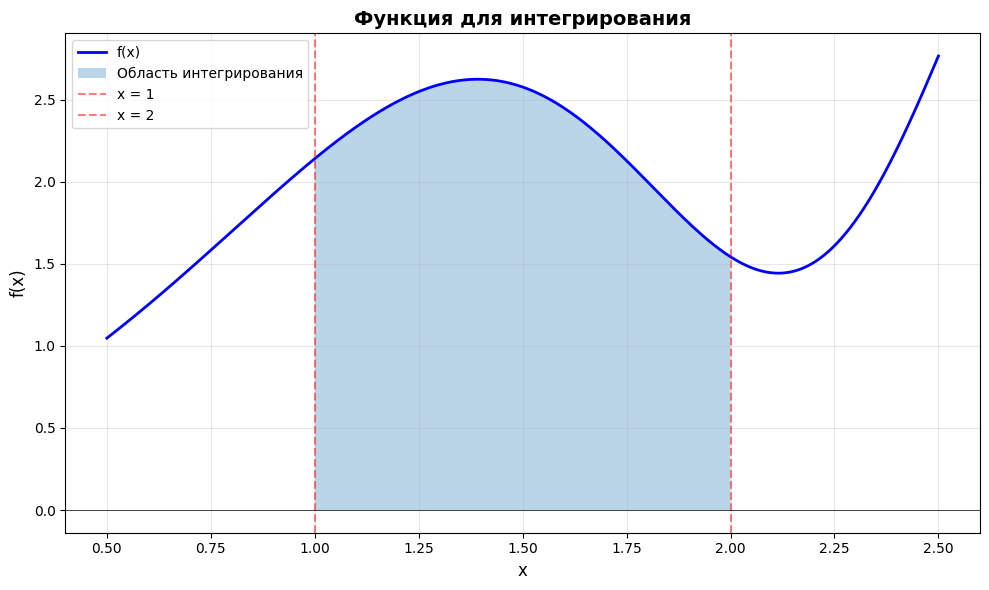

Пределы интегрирования: [1, 2]
Значение в левом пределе: F(1) = 2.1414709848078965
Значение в правом пределе: F(2) = 1.5431975046920716


In [3]:
# Демонстрация функции и её графика
x_vals = np.linspace(a - 0.5, b + 0.5, 1000)
y_vals = [F(x) for x in x_vals]

x_integral = np.linspace(a, b, 500)
y_integral = [F(x) for x in x_integral]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_vals, y_vals, 'b-', linewidth=2, label='f(x)')
ax.fill_between(x_integral, y_integral, alpha=0.3, label='Область интегрирования')
ax.axvline(x=a, color='r', linestyle='--', alpha=0.5, label=f'x = {a}')
ax.axvline(x=b, color='r', linestyle='--', alpha=0.5, label=f'x = {b}')
ax.axhline(y=0, color='k', linewidth=0.5)
ax.grid(True, alpha=0.3)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('f(x)', fontsize=12)
ax.set_title('Функция для интегрирования', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"Пределы интегрирования: [{a}, {b}]")
print(f"Значение в левом пределе: F({a}) = {F(a)}")
print(f"Значение в правом пределе: F({b}) = {F(b)}")

## 2. Решение при n=10

In [4]:
n = 10

central_rect = CentralRect().solve(F, a, b, n)
trapezoid = Trapezoid().solve(F, a, b, n)
simpson = Simpson().solve(F, a, b, n)

table = PrettyTable()
table.field_names = [" "] + [i for i in range(n)]
table.add_row(["x_i"] + [f"{i:.2f}" for i in central_rect.x])
table.add_row(["y_i"] + [f"{i:.2f}" for i in central_rect.y])

print("Центральные прямоугольники")
print(table)
print(f"Результат: {central_rect.result:.5f}")
print(f"Абсолютная погрешность: {absolute_error(exact_value, central_rect.result):.5f}")
print(f"Относительная погрешность: {relative_error(exact_value, central_rect.result):.5f} %")


print()

table = PrettyTable()
table.field_names = [" "] + [i for i in range(n + 1)]
table.add_row(["x_i"] + [f"{i:.2f}" for i in trapezoid.x])
table.add_row(["y_i"] + [f"{i:.2f}" for i in trapezoid.y])

print("Метод трапеций")
print(table)
print(f"Результат: {trapezoid.result:.5f}")
print(f"Абсолютная погрешность: {absolute_error(exact_value, trapezoid.result):.5f}")
print(f"Относительная погрешность: {relative_error(exact_value, trapezoid.result):.5f} %")


print()

table = PrettyTable()
table.field_names = [" "] + [i for i in range(n)]
table.add_row(["x_i"] + [f"{i:.2f}" for i in simpson.x])
table.add_row(["y_i"] + [f"{i:.2f}" for i in simpson.y])

print("Метод Симпсона")
print(table)
print(f"Результат: {simpson.result:.5f}")
print(f"Абсолютная погрешность: {absolute_error(exact_value, simpson.result):.5f}")
print(f"Относительная погрешность: {relative_error(exact_value, simpson.result):.5f} %")

Центральные прямоугольники
+-----+------+------+------+------+------+------+------+------+------+------+
|     |  0   |  1   |  2   |  3   |  4   |  5   |  6   |  7   |  8   |  9   |
+-----+------+------+------+------+------+------+------+------+------+------+
| x_i | 1.05 | 1.15 | 1.25 | 1.35 | 1.45 | 1.55 | 1.65 | 1.75 | 1.85 | 1.95 |
| y_i | 2.24 | 2.42 | 2.55 | 2.62 | 2.61 | 2.52 | 2.36 | 2.13 | 1.87 | 1.64 |
+-----+------+------+------+------+------+------+------+------+------+------+
Результат: 2.29606
Абсолютная погрешность: 46.29606
Относительная погрешность: 105.21831 %

Метод трапеций
+-----+------+------+------+------+------+------+------+------+------+------+------+
|     |  0   |  1   |  2   |  3   |  4   |  5   |  6   |  7   |  8   |  9   |  10  |
+-----+------+------+------+------+------+------+------+------+------+------+------+
| x_i | 1.00 | 1.10 | 1.20 | 1.30 | 1.40 | 1.50 | 1.60 | 1.70 | 1.80 | 1.90 | 2.00 |
| y_i | 2.14 | 2.34 | 2.49 | 2.59 | 2.63 | 2.58 | 2.45 | 2

## 3. Вычисление различными методами

In [5]:
epsilon = 1e-2

solver = Solver(F, a, b)
left_rect_result = solver(LeftRect(), epsilon)
right_rect_result = solver(RightRect(), epsilon)
central_rect_result = solver(CentralRect(), epsilon)
trapezoid_result = solver(Trapezoid(), epsilon)
simpson_result = solver(Simpson(), epsilon)

table = PrettyTable()
table.field_names = ["Название метода", "Вычисленное значение", "Число разбиений", "Абсолютная погрешность", "Относительная погрешность"]
table.add_rows(
    [
        [
            'Левые прямоугольники',
            f'{left_rect_result.result:.5f}',
            left_rect_result.n,
            f'{absolute_error(exact_value, left_rect_result.result):.5f}',
            f'{relative_error(exact_value, left_rect_result.result):.5f} %'
        ],
        [
            'Правые прямоугольники',
            f'{right_rect_result.result:.5f}',
            right_rect_result.n,
            f'{absolute_error(exact_value, right_rect_result.result):.5f}',
            f'{relative_error(exact_value, right_rect_result.result):.5f} %'
        ],
        [
            'Средние прямоугольники',
            f'{central_rect_result.result:.5f}',
            central_rect_result.n,
            f'{absolute_error(exact_value, central_rect_result.result):.5f}',
            f'{relative_error(exact_value, central_rect_result.result):.5f} %'
        ],
        [
            'Трапеции',
            f'{trapezoid_result.result:.5f}',
            trapezoid_result.n,
            f'{absolute_error(exact_value, trapezoid_result.result):.5f}',
            f'{relative_error(exact_value, trapezoid_result.result):.5f} %'
        ],
        [
            'Симпсон',
            f'{simpson_result.result:.5f}',
            simpson_result.n,
            f'{absolute_error(exact_value, simpson_result.result):.5f}',
            f'{relative_error(exact_value, simpson_result.result):.5f} %'
        ]
    ]
)

print(table)

+------------------------+----------------------+-----------------+------------------------+---------------------------+
|    Название метода     | Вычисленное значение | Число разбиений | Абсолютная погрешность | Относительная погрешность |
+------------------------+----------------------+-----------------+------------------------+---------------------------+
|  Левые прямоугольники  |       2.31200        |        16       |        46.31200        |        105.25454 %        |
| Правые прямоугольники  |       2.28486        |        32       |        46.28486        |        105.19286 %        |
| Средние прямоугольники |       2.30450        |        4        |        46.30450        |        105.23749 %        |
|        Трапеции        |       2.27485        |        4        |        46.27485        |        105.17010 %        |
|        Симпсон         |       2.29639        |        4        |        46.29639        |        105.21908 %        |
+------------------------+------